## 1 Create the training and validation datasets
### 1.1 Load the data


In [1]:
import pickle
import numpy as np

# Validate algorithm against training project data with known m-heights
with open('/workspace/Homework/Project1/Generated_n_k_m_P', 'rb') as f:
    all_data = pickle.load(f)
with open('/workspace/Homework/Project1/Generated_m-heights', 'rb') as f:
    all_heights = pickle.load(f)

# Filter out samples with infinite m-heights (LP unbounded — can't train on inf targets)
finite_mask = [np.isfinite(h) for h in all_heights]
training_data_full   = [all_data[i]    for i, ok in enumerate(finite_mask) if ok]
training_heights_full = [all_heights[i] for i, ok in enumerate(finite_mask) if ok]
n_inf = len(all_data) - len(training_data_full)
print(f"Filtered {n_inf} infinite-height samples ({n_inf/len(all_data)*100:.1f}%). "
      f"Keeping {len(training_data_full)} finite samples.")

# Create a 70/30 random training/validation split
from sklearn.model_selection import train_test_split
train_data, val_data, train_heights, val_heights = train_test_split(
    training_data_full, training_heights_full, test_size=0.3, random_state=42)


Filtered 0 infinite-height samples (0.0%). Keeping 768364 finite samples.


### 1.2 Pre-process the data
n=9
k is in [4,5,6]
m is in [2,..,n-k]

So we have 9 combinations for n,k,m
1. n = 9 , k = 4 , m = 2
2. n = 9 , k = 4 , m = 3
3. n = 9 , k = 4 , m = 4
4. n = 9 , k = 4 , m = 5
5. n = 9 , k = 5 , m = 2
6. n = 9 , k = 5 , m = 3
7. n = 9 , k = 5 , m = 4
8. n = 9 , k = 6 , m = 2
9. n = 9 , k = 6 , m = 3

P is a 2-dimensional numpy array of k rows and n-k columns.
Each CNN expert handles a fixed (k, m), so P is fed directly in its native 2D shape (k, n-k, 1).
We only need to normalize P to [0, 1] and log-transform the labels.


In [2]:
import numpy as np
import tensorflow as tf

def preprocess_P(P):
    # Normalize from [-100, 100] to [0, 1], keep native shape (k, n-k)
    return (P + 100) / 200.0

def preprocess_labels(heights):
    # Log transform heights; add small constant to avoid log(0)
    heights = np.array(heights)
    heights = heights + 1e-6
    return np.log(heights)

train_labels = preprocess_labels(train_heights)
val_labels   = preprocess_labels(val_heights)

print("Training labels shape:", train_labels.shape)
print("Validation labels shape:", val_labels.shape)
print("Sample training labels (first 5):", train_labels[:5])


2026-03-10 02:59:41.136865: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-10 02:59:41.341884: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-10 02:59:41.423196: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-10 02:59:41.447716: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-10 02:59:41.572357: I tensorflow/core/platform/cpu_feature_guar

Training labels shape: (537854,)
Validation labels shape: (230510,)
Sample training labels (first 5): [3.69129591 4.81929327 4.40065154 9.37139186 4.73716133]


### 2.5 Create a Mixture of Experts

In [3]:
# Note: The grading cost is (log2(y) - log2(y_hat))^2.
# Since our targets are ln(y), this equals (ln(y) - ln(y_hat))^2 / ln(2)^2.
# That is just MSE / ln(2)^2, so MSE is already proportional to the grading metric.
# No custom loss needed — standard MSE on log-transformed targets is optimal.
#
# If you still want to see it explicitly:
def log2_mse_loss(y_true, y_pred):
    """Grading-equivalent loss: (log2(y) - log2(y_hat))^2, where inputs are in ln-space."""
    ln2 = tf.cast(tf.math.log(2.0), dtype=y_true.dtype)
    return tf.reduce_mean(tf.square((y_true - y_pred) / ln2))

In [4]:
def create_cnn_moe_models():
    """
    CNN Mixture of Experts: 9 separate CNN models, one per (k, m) combination.
    Each expert receives P directly as a 2D spatial input (k x n-k x 1):
      k=4 -> input shape (4, 5, 1)
      k=5 -> input shape (5, 4, 1)
      k=6 -> input shape (6, 3, 1)
    """
    models = {}
    configs = [
        (4, 2), (4, 3), (4, 4), (4, 5),
        (5, 2), (5, 3), (5, 4),
        (6, 2), (6, 3),
    ]
    for k_val, m_val in configs:
        n_rows, n_cols = k_val, 9 - k_val
        inputs = keras.Input(shape=(n_rows, n_cols, 1), name=f'P_input_k{k_val}_m{m_val}')
        x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(32, activation='relu')(x)
        x = layers.Dropout(0.3)(x)
        output = layers.Dense(1, name='m_height_output')(x)
        model = keras.Model(inputs=inputs, outputs=output)
        model.compile(optimizer='adam', loss=log2_mse_loss, metrics=['mae'])
        models[(k_val, m_val)] = model
    return models


def train_cnn_moe_models(models, train_data, train_labels, val_data, val_labels,
                         epochs=50, batch_size=256, callbacks=None):
    """Train each CNN expert on its own (k, m) subset. P is fed as native 2D + channel."""
    histories = {}
    for (k_val, m_val), model in models.items():
        tr_idx = [i for i, (n, k, m, P) in enumerate(train_data) if k == k_val and m == m_val]
        v_idx  = [i for i, (n, k, m, P) in enumerate(val_data)   if k == k_val and m == m_val]
        X_tr = np.array([preprocess_P(train_data[i][3])[..., np.newaxis] for i in tr_idx], dtype='float32')
        y_tr = train_labels[tr_idx].astype('float32')
        X_v  = np.array([preprocess_P(val_data[i][3])[...,   np.newaxis] for i in v_idx],  dtype='float32')
        y_v  = val_labels[v_idx].astype('float32')
        expert_bs = max(32, min(batch_size, len(X_tr) // 8))
        print(f"\nCNN expert k={k_val}, m={m_val} | train={len(X_tr)}, val={len(X_v)}, "
              f"input_shape=({k_val},{9-k_val},1), bs={expert_bs}")
        ds_tr = (tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
                 .cache().shuffle(len(X_tr), seed=42).batch(expert_bs).prefetch(tf.data.AUTOTUNE))
        ds_v  = (tf.data.Dataset.from_tensor_slices((X_v, y_v))
                 .cache().batch(expert_bs).prefetch(tf.data.AUTOTUNE))
        history = model.fit(ds_tr, validation_data=ds_v, epochs=epochs, verbose=1, callbacks=callbacks)
        histories[(k_val, m_val)] = history
    return histories


def predict_cnn_moe(models, data):
    """Run each CNN expert on its matching (k, m) samples from raw data tuples."""
    predictions = np.zeros(len(data))
    for (k_val, m_val), model in models.items():
        indices = [i for i, (n, k, m, P) in enumerate(data) if k == k_val and m == m_val]
        if indices:
            Ps = np.array([preprocess_P(data[i][3])[..., np.newaxis] for i in indices], dtype='float32')
            predictions[indices] = model.predict(Ps, verbose=0).flatten()
    return predictions


### 3.5B Mixture of CNN  Experts

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

EPOCHS = 200

# --- 3.5b. CNN Mixture of Experts (9 separate CNN models, one per (k, m)) ---
print("=" * 60)
print("Training: CNN Mixture of Experts (9 experts)")
print("=" * 60)
cnn_moe_models = create_cnn_moe_models()
cnn_moe_lr_cb = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1
)
cnn_moe_histories = train_cnn_moe_models(cnn_moe_models, train_data, train_labels, val_data, val_labels,
                                          epochs=EPOCHS, batch_size=256,
                                          callbacks=[cnn_moe_lr_cb])


Training: CNN Mixture of Experts (9 experts)


I0000 00:00:1773111584.631913  488007 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1773111584.943322  488007 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1773111584.943365  488007 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1773111584.947368  488007 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1773111584.947410  488007 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0


CNN expert k=4, m=2 | train=60125, val=25647, input_shape=(4,5,1), bs=256


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
''+ptx85+ptx85' is not a recognized feature for this target' is not a recognized feature for this target (ignoring feature)
 (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

Epoch 1/200


...

209/211 [============================>.] - ETA: 0s - loss: 26.7892 - mae: 2.6897

W0000 00:00:1773113466.263321  488266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113466.263434  488266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113466.263482  488266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113466.263532  488266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113466.263585  488266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113466.263714  488266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113466.263800  488266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113466.263950  488266 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113466.264093  488266 gp

211/211 [==============================] - 2s 5ms/step - loss: 26.6437 - mae: 2.6810 - val_loss: 6.9023 - val_mae: 1.5885 - lr: 0.0010
Epoch 2/200
 37/211 [====>.........................] - ETA: 0s - loss: 8.7089 - mae: 1.6204

W0000 00:00:1773113466.493012  488268 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113466.493126  488268 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113466.493175  488268 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113466.493222  488268 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113466.493283  488268 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113466.493417  488268 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113466.493539  488268 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113466.493685  488268 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113466.493822  488268 gp

211/211 [==============================] - 1s 5ms/step - loss: 8.3189 - mae: 1.5849 - val_loss: 24.0498 - val_mae: 3.1895 - lr: 0.0010
Epoch 3/200
211/211 [==============================] - 1s 5ms/step - loss: 7.5318 - mae: 1.5084 - val_loss: 2.4485 - val_mae: 0.8312 - lr: 0.0010
Epoch 4/200
211/211 [==============================] - 1s 5ms/step - loss: 7.1492 - mae: 1.4660 - val_loss: 3.7568 - val_mae: 1.0140 - lr: 0.0010
Epoch 5/200
211/211 [==============================] - 1s 5ms/step - loss: 6.8120 - mae: 1.4326 - val_loss: 3.2238 - val_mae: 0.9276 - lr: 0.0010
Epoch 6/200
211/211 [==============================] - 1s 5ms/step - loss: 6.5996 - mae: 1.4089 - val_loss: 3.0279 - val_mae: 0.8930 - lr: 0.0010
Epoch 7/200
211/211 [==============================] - 1s 5ms/step - loss: 6.4810 - mae: 1.3976 - val_loss: 4.0150 - val_mae: 1.0697 - lr: 0.0010
Epoch 8/200
211/211 [==============================] - 1s 5ms/step - loss: 6.3102 - mae: 1.3745 - val_loss: 2.7481 - val_mae: 0.8492 - 

W0000 00:00:1773113670.744603  488267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113670.744731  488267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113670.744783  488267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113670.744833  488267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113670.744975  488267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113670.745162  488267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113670.745275  488267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113670.745432  488267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113670.745598  488267 gp


  CNN MoE — Per-group results
  (k,m)          Avg Cost    Score
  --------------------------------
  k=4,m=2          0.188242    50.0
  k=4,m=3          0.277441    50.0
  k=4,m=4          0.877218    50.0
  k=4,m=5          2.437700    50.0
  k=5,m=2          0.267479    50.0
  k=5,m=3          0.810534    50.0
  k=5,m=4          2.600976    50.0
  k=6,m=2          0.391410    50.0
  k=6,m=3          2.170139    50.0
  --------------------------------
  FINAL          1.113460    50.0/100


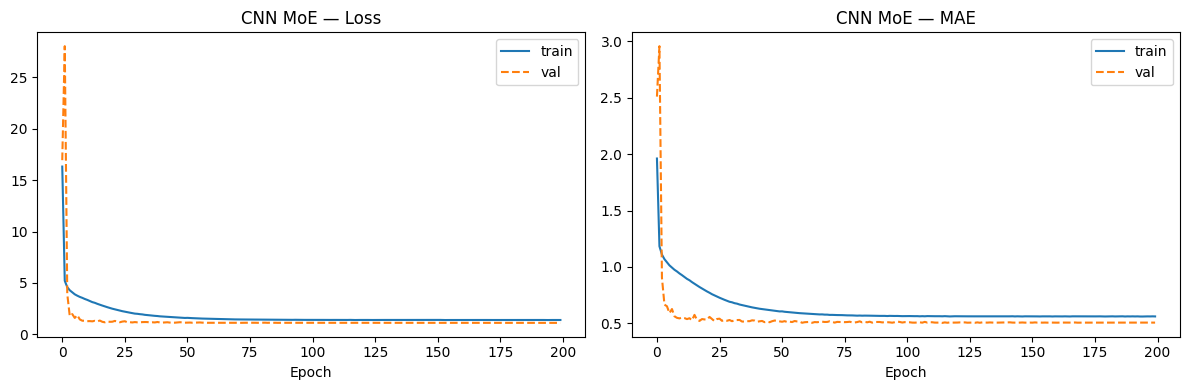

In [6]:
import matplotlib.pyplot as plt

# ── Helpers ───────────────────────────────────────────────────────────────────

def get_group_costs(predictions_log, data, labels_log):
    """
    Compute per-(k,m) average grading cost: (log2(y) - log2(y_hat))^2.
    predictions_log and labels_log are in ln-space.
    """
    y_pred   = np.maximum(np.exp(predictions_log), 1.0)
    y_actual = np.exp(labels_log)
    cost_per_sample = (np.log2(y_actual) - np.log2(y_pred)) ** 2
    group_costs = {}
    for i, (n, k, m, P) in enumerate(data):
        group_costs.setdefault((k, m), []).append(cost_per_sample[i])
    return {km: np.nanmean(costs) for km, costs in group_costs.items()}


def grade_model(group_costs, all_reference_costs=None):
    """
    Grade a single model using the project scoring formula.
    If all_reference_costs is None, the model is graded against itself only
    (every group gets 50 — useful for sanity checking absolute cost).
    Pass a list of group_cost dicts (one per 'student') to get relative scoring.
    """
    if all_reference_costs is None:
        all_reference_costs = [group_costs]

    groups = sorted(group_costs.keys())
    group_scores = {}

    for grp in groups:
        costs = np.array([gc[grp] for gc in all_reference_costs if grp in gc], dtype=float)
        costs = costs[np.isfinite(costs)]  # drop NaN/inf before sorting
        if len(costs) == 0:
            group_scores[grp] = 0.0
            continue
        sorted_costs = np.sort(costs)
        M = len(sorted_costs)
        theta = sorted_costs[int(np.ceil(M / 2)) - 1]
        q25   = sorted_costs[int(np.ceil(M / 4)) - 1]
        alpha = np.log(3) / (theta - q25) if (theta - q25) > 1e-12 else 100.0
        denom = 100.0 / (np.exp(np.clip(-alpha * theta, -500, 500)) + 1) - 50
        if abs(denom) < 1e-12:
            denom = 1e-12
        sigma = group_costs[grp]
        if not np.isfinite(sigma):
            group_scores[grp] = 0.0
            continue
        exp_arg = np.clip(alpha * (sigma - theta), -500, 500)
        beta = max(
            (100.0 / (np.exp(exp_arg) + 1) - 50) * 50.0 / denom + 50,
            0.0
        )
        group_scores[grp] = beta

    final_score = np.mean(list(group_scores.values()))
    return group_scores, final_score

# ── Evaluate CNN MoE ──────────────────────────────────────────────────────────

cnn_moe_preds = predict_cnn_moe(cnn_moe_models, val_data)
nan_count = np.sum(np.isnan(cnn_moe_preds))
if nan_count > 0:
    print(f"WARNING: {nan_count} NaN predictions detected — model may need retraining.")
cnn_group_costs = get_group_costs(cnn_moe_preds, val_data, val_labels)
cnn_group_scores, cnn_final_score = grade_model(cnn_group_costs)

# ── Per-group results table ───────────────────────────────────────────────────

groups = sorted(cnn_group_costs.keys())
print(f"\n{'=' * 55}")
print(f"  CNN MoE — Per-group results")
print(f"{'=' * 55}")
print(f"  {'(k,m)':<10} {'Avg Cost':>12} {'Score':>8}")
print(f"  {'-' * 32}")
for grp in groups:
    print(f"  k={grp[0]},m={grp[1]:<6} {cnn_group_costs[grp]:>12.6f} {cnn_group_scores[grp]:>7.1f}")
print(f"  {'-' * 32}")
print(f"  {'FINAL':<10} {np.mean(list(cnn_group_costs.values())):>12.6f} {cnn_final_score:>7.1f}/100")
print(f"{'=' * 55}")

# ── Training curves ───────────────────────────────────────────────────────────

def avg_moe_curves(histories):
    """Average training curves across experts, truncated to shortest history."""
    keys = ['loss', 'val_loss', 'mae', 'val_mae']
    arrays = {k: [h.history[k] for h in histories.values()] for k in keys}
    min_len = min(len(v) for v in arrays['loss'])
    return {k: np.mean([x[:min_len] for x in arrays[k]], axis=0) for k in keys}

curves = avg_moe_curves(cnn_moe_histories)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(curves['loss'],     label='train')
axes[0].plot(curves['val_loss'], label='val', linestyle='--')
axes[0].set_title('CNN MoE — Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(curves['mae'],     label='train')
axes[1].plot(curves['val_mae'], label='val', linestyle='--')
axes[1].set_title('CNN MoE — MAE'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.show()


In [7]:
# Validate algorithm against our original data - we will use it as a test set for our final models
with open('/workspace/Homework/Project1/CSCE-636-Project-1-Train-n_k_m_P', 'rb') as f:
    test_data = pickle.load(f)
with open('/workspace/Homework/Project1/CSCE-636-Project-1-Train-mHeights', 'rb') as f:
    test_expected_heights = pickle.load(f)

In [8]:
# Use the model to predict the heights for the original training data and score
predicted_heights_log = predict_cnn_moe(cnn_moe_models, test_data)

test_group_costs = get_group_costs(predicted_heights_log, test_data, preprocess_labels(test_expected_heights))
test_group_scores, test_final_score = grade_model(test_group_costs)

print(f"\n{'=' * 55}")
print(f"  CNN MoE — Test set results (original training data)")
print(f"{'=' * 55}")
print(f"  {'(k,m)':<10} {'Avg Cost':>12} {'Score':>8}")
print(f"  {'-' * 32}")
for grp in sorted(test_group_costs.keys()):
    print(f"  k={grp[0]},m={grp[1]:<6} {test_group_costs[grp]:>12.6f} {test_group_scores[grp]:>7.1f}")
print(f"  {'-' * 32}")
print(f"  {'FINAL':<10} {np.mean(list(test_group_costs.values())):>12.6f} {test_final_score:>7.1f}/100")
print(f"{'=' * 55}")


W0000 00:00:1773113680.711785  488264 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113680.711901  488264 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113680.711944  488264 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113680.712007  488264 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113680.712149  488264 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113680.712347  488264 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113680.712442  488264 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113680.712599  488264 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113680.712736  488264 gp


  CNN MoE — Test set results (original training data)
  (k,m)          Avg Cost    Score
  --------------------------------
  k=4,m=2          0.650125    50.0
  k=4,m=3          0.579086    50.0
  k=4,m=4          1.143794    50.0
  k=4,m=5          3.039923    50.0
  k=5,m=2          0.552452    50.0
  k=5,m=3          0.982203    50.0
  k=5,m=4          3.064183    50.0
  k=6,m=2          0.484190    50.0
  k=6,m=3          2.396445    50.0
  --------------------------------
  FINAL          1.432489    50.0/100


W0000 00:00:1773113684.658408  488267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113684.658513  488267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113684.658554  488267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113684.658616  488267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113684.658669  488267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113684.658715  488267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113684.658796  488267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113684.659717  488267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773113684.659812  488267 gp